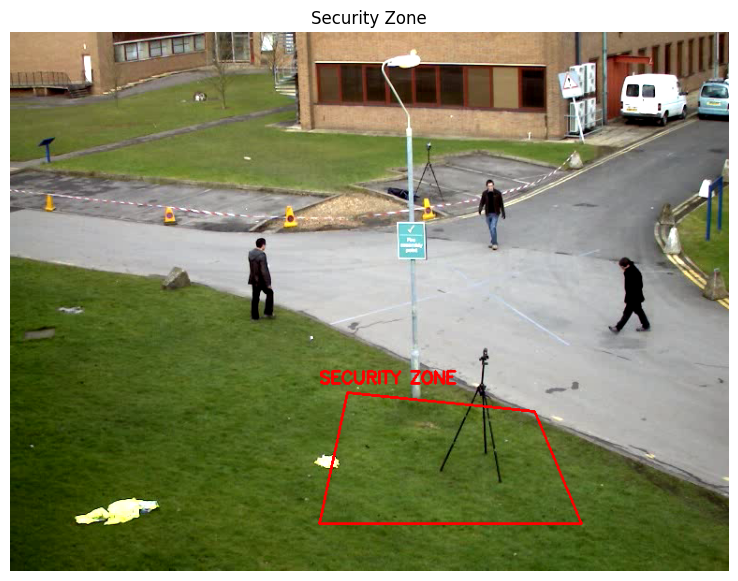

Alarm started at frame 450 ( 45.0 sec )
Total frames: 795
Frames with alarm: 345


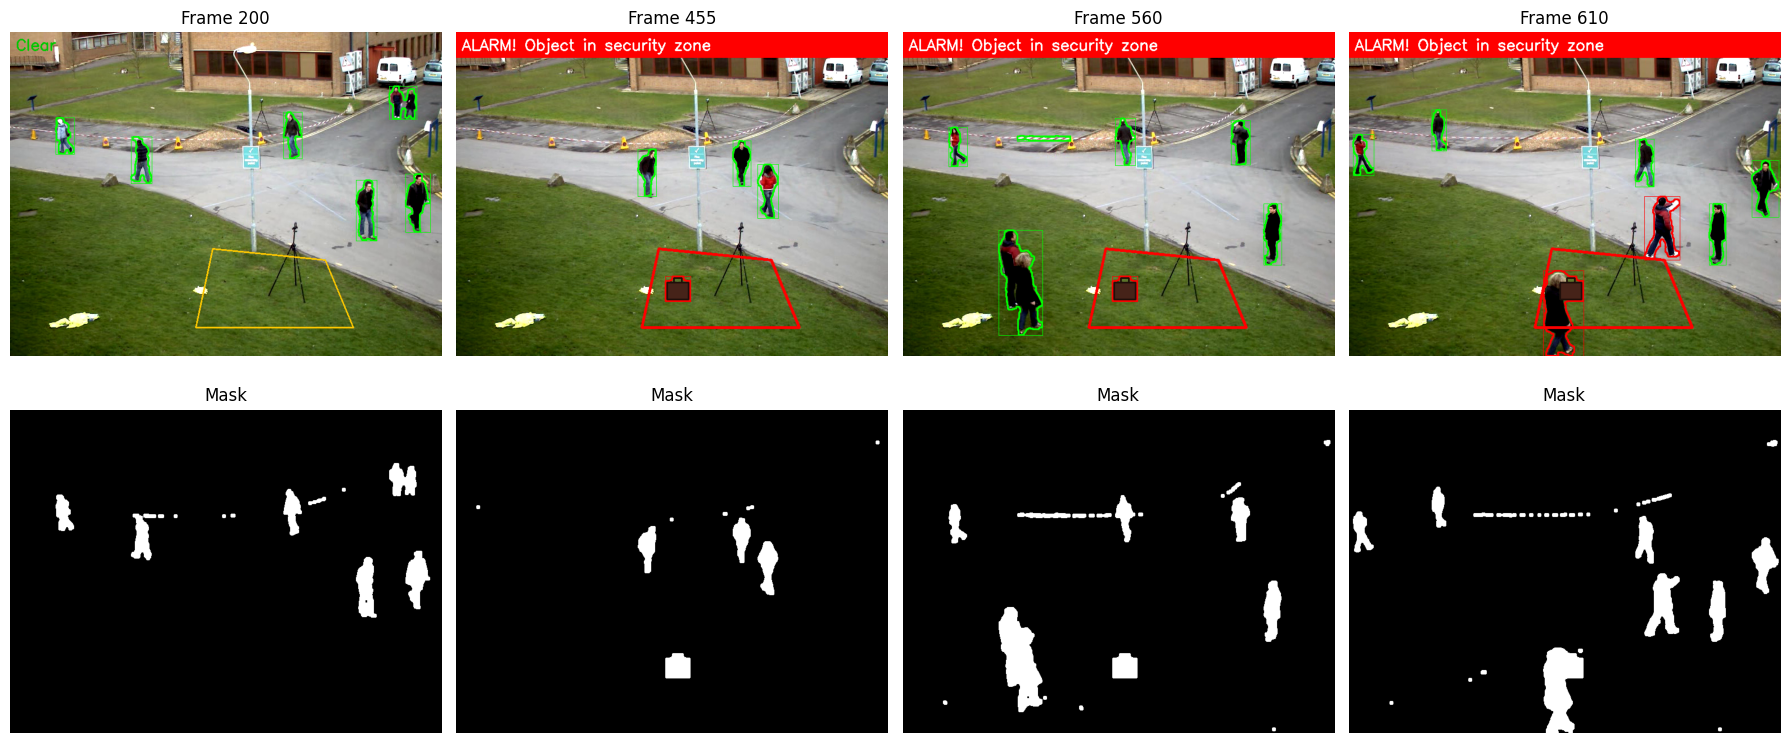

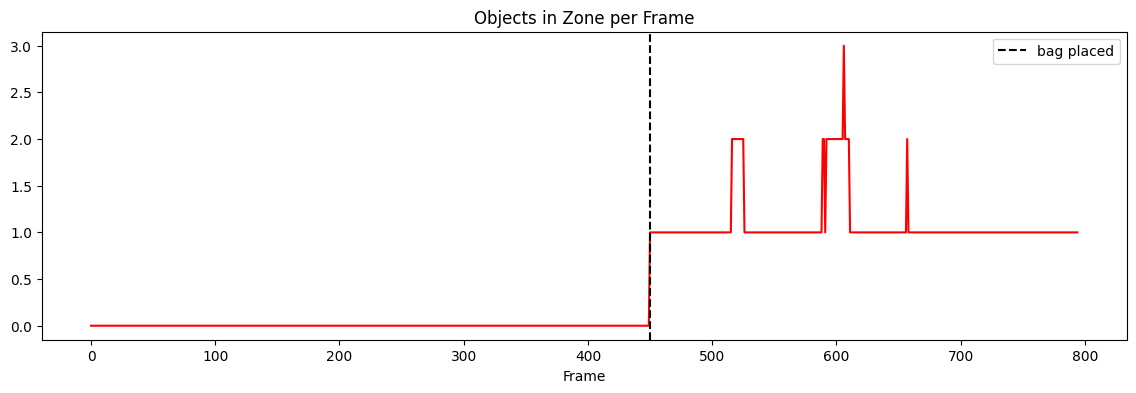

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Video (use 0 for webcam)
video_path = "vtest.avi"

# Security zone (area around the camera stand on the grass)
zone = np.array([[360, 385], [560, 405], [610, 525], [330, 525]], np.int32)

# Read first frame to see the zone
cap = cv2.VideoCapture(video_path)
ret, first_frame = cap.read()
cap.release()
if not ret:
    print("Video not found, check the path")

zone_image = first_frame.copy()
cv2.polylines(zone_image, [zone], True, (0, 0, 255), 2)
cv2.putText(zone_image, "SECURITY ZONE", (330, 375), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(zone_image, cv2.COLOR_BGR2RGB))
plt.title("Security Zone")
plt.axis("off")
plt.show()

# a bag will be placed in the zone at frame 450 (to test a left object)
def add_bag(frame):
    x, y = 375, 445
    cv2.rectangle(frame, (x, y), (x + 38, y + 30), (25, 35, 70), -1)
    cv2.rectangle(frame, (x, y), (x + 38, y + 30), (10, 15, 30), 2)
    cv2.rectangle(frame, (x + 12, y - 8), (x + 26, y), (10, 15, 30), 2)
    return frame

# Open video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Save result video
out = cv2.VideoWriter("security_result.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

# zone as a mask
zone_mask = np.zeros((height, width), np.uint8)
cv2.fillPoly(zone_mask, [zone], 255)

# Background subtractor (finds moving / new objects)
bg = cv2.createBackgroundSubtractorMOG2(history=300, varThreshold=40, detectShadows=True)

# kernels for cleaning the mask
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
kernel_big = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

frame_no = 0
alarm_frames = 0
alarm_on = False
alarm_list = []
saved_frames = {}

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_no >= 450:
        frame = add_bag(frame)

    # first 60 frames only learn the background
    # after that learning is very slow so the bag does not disappear
    if frame_no < 60:
        fg_mask = bg.apply(frame)
    else:
        fg_mask = bg.apply(frame, learningRate=0.0001)

    # remove shadows (shadows are 127 in MOG2)
    _, fg_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)

    # opening removes small noise, closing fills holes
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel_small)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel_big)
    fg_mask = cv2.dilate(fg_mask, None, iterations=2)

    # Boundary detection
    contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    result = frame.copy()
    objects_in_zone = 0

    if frame_no >= 60:
        for c in contours:
            # ignore very small blobs
            if cv2.contourArea(c) < 350:
                continue

            x, y, w, h = cv2.boundingRect(c)

            # bottom center point of the object (feet)
            foot = (x + w // 2, y + h)
            foot_inside = cv2.pointPolygonTest(zone, foot, False) >= 0

            # how much of the object is inside the zone
            obj = fg_mask[y:y + h, x:x + w]
            obj_in_zone = cv2.bitwise_and(obj, zone_mask[y:y + h, x:x + w])
            overlap = np.count_nonzero(obj_in_zone) / max(1, np.count_nonzero(obj))

            if foot_inside or overlap > 0.3:
                color = (0, 0, 255)       # red = inside zone
                objects_in_zone += 1
            else:
                color = (0, 255, 0)       # green = outside zone

            cv2.drawContours(result, [c], -1, color, 2)
            cv2.rectangle(result, (x, y), (x + w, y + h), color, 1)

    # Alarm
    if objects_in_zone > 0:
        alarm_frames += 1
        cv2.polylines(result, [zone], True, (0, 0, 255), 3)
        cv2.rectangle(result, (0, 0), (width, 45), (0, 0, 255), -1)
        cv2.putText(result, "ALARM! Object in security zone", (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
        if alarm_on == False:
            print("Alarm started at frame", frame_no, "(", round(frame_no / fps, 1), "sec )")
        alarm_on = True
    else:
        cv2.polylines(result, [zone], True, (0, 200, 255), 2)
        cv2.putText(result, "Clear", (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 200, 0), 2)
        if alarm_on == True:
            print("Alarm stopped at frame", frame_no)
        alarm_on = False

    alarm_list.append(objects_in_zone)
    out.write(result)

    # save some frames to show
    if frame_no in [200, 455, 560, 610]:
        saved_frames[frame_no] = (result, fg_mask)

    frame_no += 1

cap.release()
out.release()

print("Total frames:", frame_no)
print("Frames with alarm:", alarm_frames)

# Show some frames and their masks
plt.figure(figsize=(18, 8))
i = 1
for f in saved_frames:
    plt.subplot(2, 4, i)
    plt.imshow(cv2.cvtColor(saved_frames[f][0], cv2.COLOR_BGR2RGB))
    plt.title("Frame " + str(f))
    plt.axis("off")

    plt.subplot(2, 4, i + 4)
    plt.imshow(saved_frames[f][1], cmap="gray")
    plt.title("Mask")
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()

# Alarm graph
plt.figure(figsize=(14, 4))
plt.plot(alarm_list, color="red")
plt.axvline(450, color="black", linestyle="--", label="bag placed")
plt.title("Objects in Zone per Frame")
plt.xlabel("Frame")
plt.legend()
plt.show()